# Model 1 - GRU
## 1. Load dataset and requirements

In [1]:
from datasets import load_dataset
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

ds = load_dataset("Adilbai/stock-dataset")
df = ds["train"].to_pandas()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/336M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/620095 [00:00<?, ? examples/s]

## 2. Choose target columns

In [2]:
TARGET_COL = "Future_Up_1d" # regression target (recommended)

# Columns that should NOT be used as input features
leakage_cols = [
    "Future_Return_1d", "Future_Up_1d", "Future_Category_1d",
    "Future_Return_5d", "Future_Up_5d", "Future_Category_5d",
    "Future_Return_10d", "Future_Up_10d", "Future_Category_10d",
    "Future_Return_20d", "Future_Up_20d", "Future_Category_20d",
]

# Non-numeric / identifiers (we won't feed these directly into GRU)
id_cols = ["Date", "Ticker"]

# Build feature list: numeric columns excluding leakage + ids
feature_cols = []
for c in df.columns:
    if c in leakage_cols or c in id_cols:
        continue
    # keep only numeric columns
    if pd.api.types.is_numeric_dtype(df[c]):
        feature_cols.append(c)

# Drop rows with missing required values
df = df.dropna(subset=feature_cols + [TARGET_COL, "Ticker", "Date"]).copy()

# Ensure Date sorted within each ticker
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

print("Num rows:", len(df))
print("Num features:", len(feature_cols))

/tmp/ipykernel_2496/2942265520.py:27: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["Date"] = pd.to_datetime(df["Date"])


Num rows: 620095
Num features: 59


## 3. Time-based split

In [3]:
split_date = df["Date"].quantile(0.8)  # 80/20 split by time
train_df = df[df["Date"] <= split_date].copy()
val_df   = df[df["Date"] >  split_date].copy()

# Normalize features using TRAIN only
train_mean = train_df[feature_cols].mean()
train_std = train_df[feature_cols].std().replace(0, 1.0)

train_df[feature_cols] = (train_df[feature_cols] - train_mean) / train_std
val_df[feature_cols]   = (val_df[feature_cols] - train_mean) / train_std

## 4 Dataset that creates sliding windows per ticker

In [4]:
class StockSequenceDataset(Dataset):
    def __init__(self, data: pd.DataFrame, feature_cols, target_col, seq_len=20):
        self.feature_cols = feature_cols
        self.target_col = target_col
        self.seq_len = seq_len

        # group rows by ticker (already sorted by date)
        self.groups = []
        for ticker, g in data.groupby("Ticker", sort=False):
            g = g.reset_index(drop=True)
            # need at least seq_len rows + 1 target aligned at the last row of window
            if len(g) >= seq_len:
                self.groups.append(g)

        # build index of (group_id, end_index) where end_index is last index in window
        self.indices = []
        for gi, g in enumerate(self.groups):
            for end in range(seq_len - 1, len(g)):
                self.indices.append((gi, end))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        gi, end = self.indices[idx]
        g = self.groups[gi]

        start = end - self.seq_len + 1
        x = g.loc[start:end, self.feature_cols].to_numpy(dtype=np.float32)
        y = np.float32(g.loc[end, self.target_col])

        return torch.from_numpy(x), torch.tensor(y)

SEQ_LEN = 20
BATCH_SIZE = 256

train_dataset = StockSequenceDataset(train_df, feature_cols, TARGET_COL, seq_len=SEQ_LEN)
val_dataset   = StockSequenceDataset(val_df, feature_cols, TARGET_COL, seq_len=SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train sequences:", len(train_dataset))
print("Val sequences:", len(val_dataset))

Train sequences: 486831
Val sequences: 114169


## 5.1. Basic GRU Regressor (RNN model)

In [ ]:
class GRURegressor(nn.Module):
    def __init__(self, num_features, hidden_dim=64):
        super().__init__()
        self.gru = nn.GRU(
            input_size=num_features,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        last = out[:, -1, :]
        return self.fc(last).squeeze(1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GRURegressor(num_features=len(feature_cols)).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

## 6. Train GRU Model

In [6]:
# old train
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x)o
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_one_epoch(model, loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        correct += (preds == y).sum().item()
        total += y.size(0)

    acc = correct / total
    return total_loss / len(loader.dataset), acc

train_accs = []
val_accs = []
EPOCHS = 10
for epoch in range(1, EPOCHS + 1):
    # ---- training ----
    model.train()
    correct = 0
    total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        correct += (preds == y).sum().item()
        total += y.size(0)

    train_acc = correct / total
    train_accs.append(train_acc)

    # ---- validation ----
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            logits = model(x)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

            correct += (preds == y).sum().item()
            total += y.size(0)

    val_acc = correct / total
    val_accs.append(val_acc)
    print(f"Epoch {epoch} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1 | Train Acc: 0.5207 | Val Acc: 0.5086
Epoch 2 | Train Acc: 0.5429 | Val Acc: 0.5133
Epoch 3 | Train Acc: 0.5653 | Val Acc: 0.5145


KeyboardInterrupt: 

In [ ]:
# new train
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        correct += (preds == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / len(loader.dataset)
    acc = correct / total
    return avg_loss, acc


@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        correct += (preds == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / len(loader.dataset)
    acc = correct / total
    return avg_loss, acc

In [ ]:
train_losses = []
train_accs = []
val_losses = []
val_accs = []

best_val_loss = float("inf")
patience = 3
counter = 0

EPOCHS = 20

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = eval_one_epoch(model, val_loader, criterion, device)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

    # --- early stopping logic ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        best_model_state = model.state_dict()  # save best model
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

# restore best model
model.load_state_dict(best_model_state)

Epoch 01 | Train Loss: 0.6360 | Train Acc: 0.6095 | Val Loss: 0.7014 | Val Acc: 0.5146
Epoch 02 | Train Loss: 0.6322 | Train Acc: 0.6131 | Val Loss: 0.7064 | Val Acc: 0.5147
Epoch 03 | Train Loss: 0.6286 | Train Acc: 0.6180 | Val Loss: 0.7046 | Val Acc: 0.5143


In [ ]:
import matplotlib.pyplot as plt
epochs = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epochs, train_accs)
plt.plot(epochs, val_accs)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend(["Train", "Validation"])

plt.show()

## model LSTM

In [ ]:
TARGET_COL = "Future_Up_1d"

leakage_cols = [
    "Future_Return_1d", "Future_Up_1d", "Future_Category_1d",
    "Future_Return_5d", "Future_Up_5d", "Future_Category_5d",
    "Future_Return_10d", "Future_Up_10d", "Future_Category_10d",
    "Future_Return_20d", "Future_Up_20d", "Future_Category_20d",
]

id_cols = ["Date", "Ticker"]

feature_cols = []
for c in df.columns:
    if c in leakage_cols or c in id_cols:
        continue
    if pd.api.types.is_numeric_dtype(df[c]):
        feature_cols.append(c)

# Drop missing rows
df = df.dropna(subset=feature_cols + [TARGET_COL, "Ticker", "Date"]).copy()

# Sort properly
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

print("Num rows:", len(df))
print("Num features:", len(feature_cols))

# ---- split date based on full panel time ----
split_date = df["Date"].quantile(0.8)
print("Split date:", split_date)

# ---- fit normalization on TRAIN ROWS ONLY ----
train_mask = df["Date"] <= split_date

train_mean = df.loc[train_mask, feature_cols].mean()
train_std  = df.loc[train_mask, feature_cols].std().replace(0, 1.0)

# normalize full df using train stats
df_norm = df.copy()
df_norm[feature_cols] = (df_norm[feature_cols] - train_mean) / train_std


class StockSequenceDataset(Dataset):
    def __init__(self, data: pd.DataFrame, feature_cols, target_col, split_date, seq_len=20, split="train"):
        self.feature_cols = feature_cols
        self.target_col = target_col
        self.seq_len = seq_len
        self.split = split
        self.split_date = pd.Timestamp(split_date)

        self.groups = []
        self.indices = []

        # build groups ticker by ticker
        for ticker, g in data.groupby("Ticker", sort=False):
            g = g.sort_values("Date").reset_index(drop=True)

            if len(g) < seq_len:
                continue

            group_id = len(self.groups)
            self.groups.append(g)

            # build all possible windows from full ticker history
            for end in range(seq_len - 1, len(g)):
                label_date = g.loc[end, "Date"]

                if split == "train" and label_date <= self.split_date:
                    self.indices.append((group_id, end))

                elif split == "val" and label_date > self.split_date:
                    self.indices.append((group_id, end))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        gi, end = self.indices[idx]
        g = self.groups[gi]

        start = end - self.seq_len + 1

        x = g.loc[start:end, self.feature_cols].to_numpy(dtype=np.float32)
        y = np.float32(g.loc[end, self.target_col])

        return torch.from_numpy(x), torch.tensor(y, dtype=torch.float32)


SEQ_LEN = 20
BATCH_SIZE = 256

train_dataset = StockSequenceDataset(
    df_norm,
    feature_cols,
    TARGET_COL,
    split_date=split_date,
    seq_len=SEQ_LEN,
    split="train"
)

val_dataset = StockSequenceDataset(
    df_norm,
    feature_cols,
    TARGET_COL,
    split_date=split_date,
    seq_len=SEQ_LEN,
    split="val"
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train sequences:", len(train_dataset))
print("Val sequences:", len(val_dataset))

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

class LSTMClassifier(nn.Module):
    def __init__(self, num_features, hidden_dim=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=num_features,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)   # out: (batch, seq_len, hidden_dim)
        last = out[:, -1, :]             # take final timestep
        logits = self.fc(last).squeeze(1)
        return logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMClassifier(
    num_features=len(feature_cols),
    hidden_dim=64,
    num_layers=1,
    dropout=0.2
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [6]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).float()

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / len(loader.dataset), correct / total


@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).float()

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / len(loader.dataset), correct / total

In [7]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_loss = float("inf")
best_model_state = None
patience = 3
counter = 0
EPOCHS = 10

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = eval_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

if best_model_state is not None:
    model.load_state_dict(best_model_state)

Epoch 01 | Train Loss: 0.6914 | Train Acc: 0.5216 | Val Loss: 0.6932 | Val Acc: 0.5108
Epoch 02 | Train Loss: 0.6897 | Train Acc: 0.5303 | Val Loss: 0.6942 | Val Acc: 0.5100
Epoch 03 | Train Loss: 0.6881 | Train Acc: 0.5368 | Val Loss: 0.6935 | Val Acc: 0.5145
Epoch 04 | Train Loss: 0.6865 | Train Acc: 0.5418 | Val Loss: 0.6936 | Val Acc: 0.5166
Early stopping triggered.


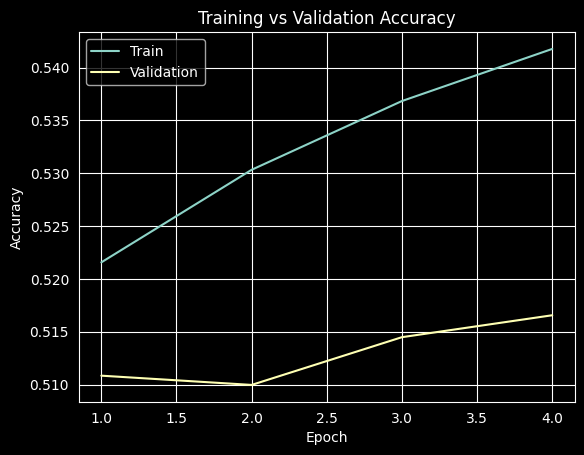

In [8]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_accs) + 1)

plt.figure()
plt.plot(epochs, train_accs)
plt.plot(epochs, val_accs)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend(["Train", "Validation"])
plt.show()